In [163]:
import cmocean.cm as cm
import copy
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import xarray as xr

#from salishsea_tools import visualisations as vis
from salishsea_tools import viz_tools

In [164]:
plt.rcParams['font.size'] = 15
cm_haline = copy.copy(cm.haline)
cm_haline.set_bad('k')

In [165]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')
tmask = mesh['tmask'][0]
deptht = mesh['gdept_1d'][0]
#mesh_mask_depth_var='gdept_0'

In [166]:
salishdir = Path('/results2/SalishSea/nowcast-green.202111/')

In [167]:
step = 2
yearrange = [2007, 2025]
thisyear = 2026
today = dt.datetime(2026, 3, 23)

In [168]:
def mymask(field, dl):
    return np.ma.array(field, mask=1-tmask[dl*step, ::step, ::step])

In [169]:
history = np.zeros((yearrange[1] - yearrange[0] + 1, int(40/step), int((898+1)/step), int((398+1)/step)))
now = np.zeros((int(40/step), int((898+2)/step), int((398+2)/step)))

In [170]:
print (history.shape)
nz = history.shape[1]
number_values = tmask[::step, ::step, ::step].sum(axis=2).sum(axis=1).values
number_values

(19, 20, 449, 199)


array([20378, 20378, 20110, 19867, 19588, 19262, 18982, 18642, 18327,
       17985, 17413, 16375, 14505, 11613,  8509,  5214,  3164,  2118,
        1196,   600])

In [171]:
for iy, year in enumerate(range(yearrange[0], yearrange[1]+1)):
    dirstring = dt.datetime(year, today.month, today.day).strftime("%d%b%y").lower()
    timestring = f'{year}{today.month:02d}{today.day:02d}'
    datafile = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_grid_T.nc')
    history[iy] = datafile.vosaline[0, ::step, ::step, ::step]
    datafile.close()

In [172]:
dirstring = today.strftime("%d%b%y").lower()
timestring = f'{today.year}{today.month:02d}{today.day:02d}'
datafile = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_grid_T.nc')
now = datafile.vosaline[0, ::step, ::step, ::step]
datafile.close()

In [173]:
max_values = mymask(history.max(axis=0), np.arange(nz))
min_values = mymask(history.min(axis=0), np.arange(nz))
median_values = mymask(np.median(history, axis=0), np.arange(nz))
high_values = mymask(np.quantile(history, 0.75, axis=0), np.arange(nz))
low_values = mymask(np.quantile(history, 0.25, axis=0), np.arange(nz))

In [174]:
min_mask = now < min_values
max_mask = now > max_values
lower_mask = now < median_values
upper_mask = now > median_values
low_mask = now < low_values
high_mask = now > high_values

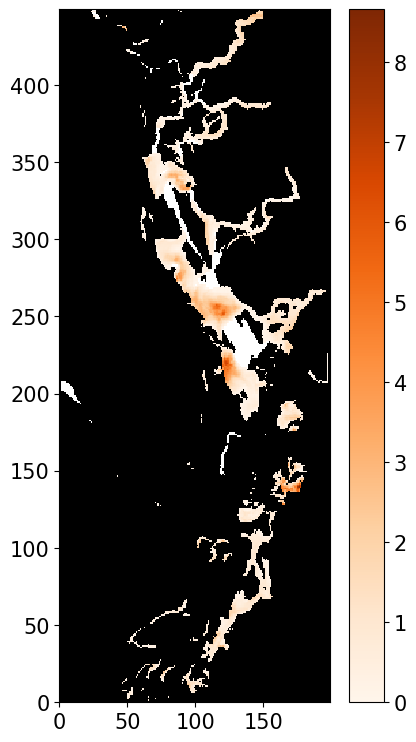

In [213]:
fig, ax = plt.subplots(1, 1, figsize=(5, 9))
now_values = mymask(now, np.arange(nz))
extreme_high = (now_values - max_values) / (high_values-low_values)
extreme_high.mask[extreme_high < 0] = True
zmaxhigh = np.argmax(extreme_high.count(axis=2).sum(axis=1)/number_values)
extreme_low = (min_values - now_values) / (high_values-low_values)
extreme_low.mask[extreme_low < 0] = True
zmaxlow = np.argmax(extreme_low.count(axis=2).sum(axis=1)/number_values)
if extreme_high[zmaxhigh].count() > extreme_low[zmaxlow].count():
    extreme = 'high'
else:
    extreme = 'low'
ax.pcolormesh(tmask[dl*step, ::step, ::step], cmap='binary_r')
if extreme == 'low':
    colours = ax.pcolormesh(extreme_low[zmaxlow], cmap='Oranges')
    fig.colorbar(colours, ax=ax)
viz_tools.set_aspect(ax);

Depth is 0.5000002726328603


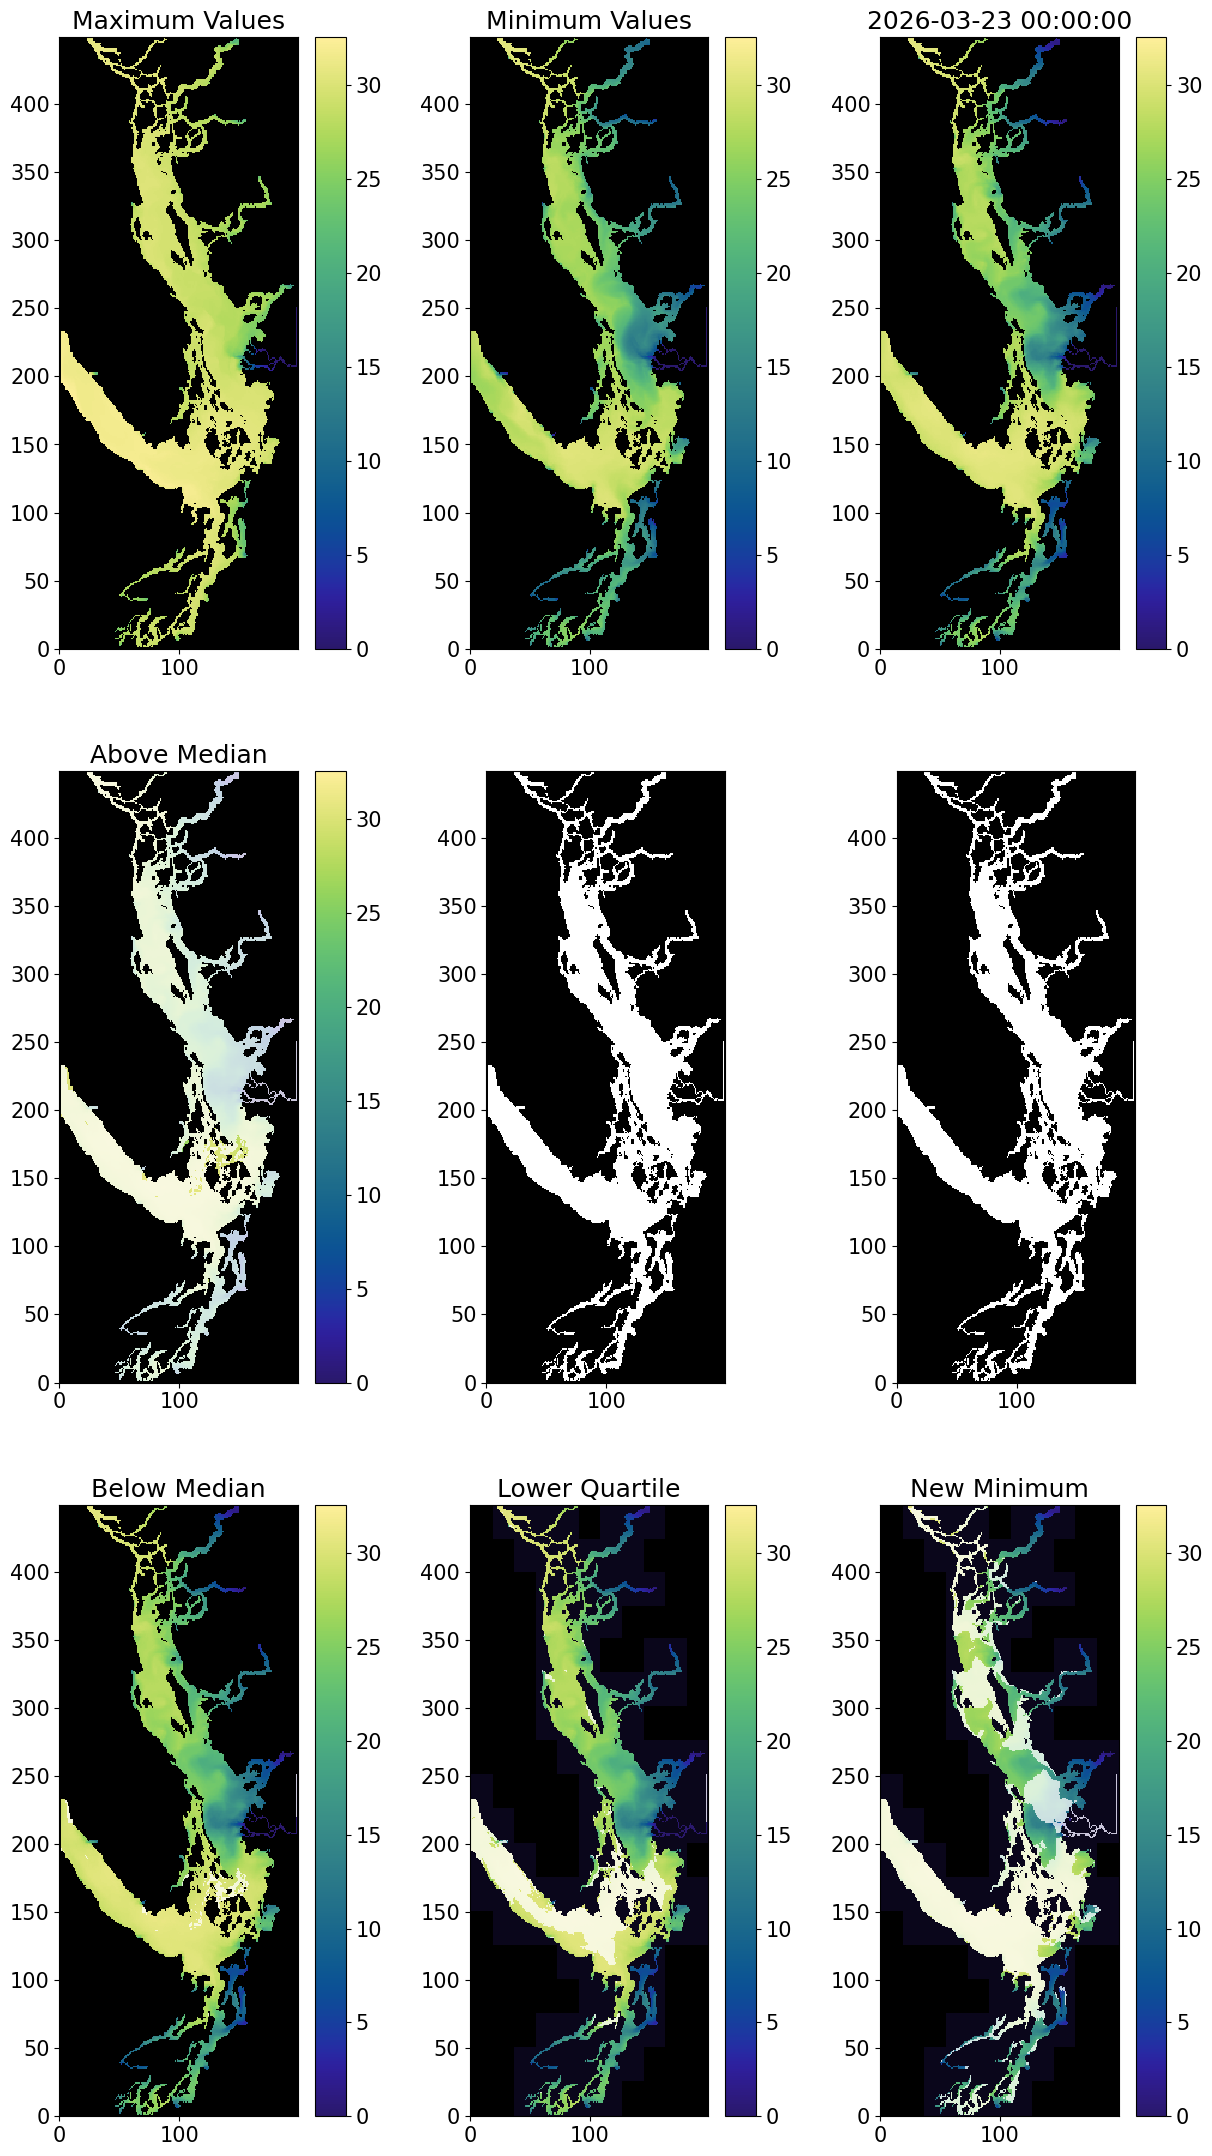

In [176]:
fig, axs = plt.subplots(3, 3, figsize=(15, 27))
if extreme == 'low':
    dl = zmaxlow
else:
    dl = zmaxhigh
print (f'Depth is {deptht[dl*step].values}')
cmapb = cm_haline
cmap = cm.haline
alpha = 0.25
needed = max_values[dl]
vmax = np.nanmax(needed[needed !=0])
needed = min_values[dl]
vmin = np.nanmin(needed[needed !=0])

for ax in axs.flatten():
    ax.pcolormesh(tmask[dl*step, ::step, ::step], cmap='binary_r')

# First Row
colours = axs[0, 0].pcolormesh(mymask(max_values[dl], dl), vmin=vmin, vmax=vmax, cmap=cmap)
fig.colorbar(colours, ax=axs[0, 0]);
axs[0, 0].set_title('Maximum Values')

colours = axs[0, 1].pcolormesh(mymask(min_values[dl], dl), vmin=vmin, vmax=vmax, cmap=cmap)
fig.colorbar(colours, ax=axs[0, 1]);
axs[0, 1].set_title('Minimum Values')

colours = axs[0, 2].pcolormesh(mymask(now[dl], dl), vmin=vmin, vmax=vmax, cmap=cmap)
fig.colorbar(colours, ax=axs[0, 2])
axs[0, 2].set_title(f'{today}')

# Second Row
colours = axs[1, 0].pcolormesh(np.ma.array(now[dl], mask=1-upper_mask[dl]), vmin=vmin, vmax=vmax, cmap=cmap)
axs[1, 0].pcolormesh(mymask(now[dl], dl), vmax=vmax, cmap=ocmap, alpha=alpha)
fig.colorbar(colours, ax=axs[1, 0])
axs[1, 0].set_title('Above Median')

# Third Row
axs[2, 0].pcolormesh(mymask(now[dl], dl), vmax=vmax, cmap=cmap, alpha=alpha)
colours = axs[2, 0].pcolormesh(np.ma.array(now[dl],mask=1-lower_mask[dl]), vmin=vmin, vmax=vmax, cmap=cmap)
fig.colorbar(colours, ax=axs[2, 0])
axs[2, 0].set_title('Below Median')

axs[2, 1].pcolormesh(now[dl], vmax=vmax, alpha=alpha, cmap=cmap)
colours = axs[2, 1].pcolormesh(np.ma.array(now[dl], mask=1-low_mask[dl]), vmin=vmin, vmax=vmax, cmap=cmap)
fig.colorbar(colours, ax=axs[2, 1])
axs[2, 1].set_title('Lower Quartile')

axs[2, 2].pcolormesh(now[dl], vmax=vmax, alpha=alpha, cmap=cmap)
colours = axs[2, 2].pcolormesh(np.ma.array(now[dl],mask=1-min_mask[dl]), vmin=vmin, vmax=vmax, cmap=cmap)
axs[2, 2].set_title('New Minimum');
fig.colorbar(colours, ax=axs[2, 2]);

for ax in axs.flatten():
        viz_tools.set_aspect(ax)

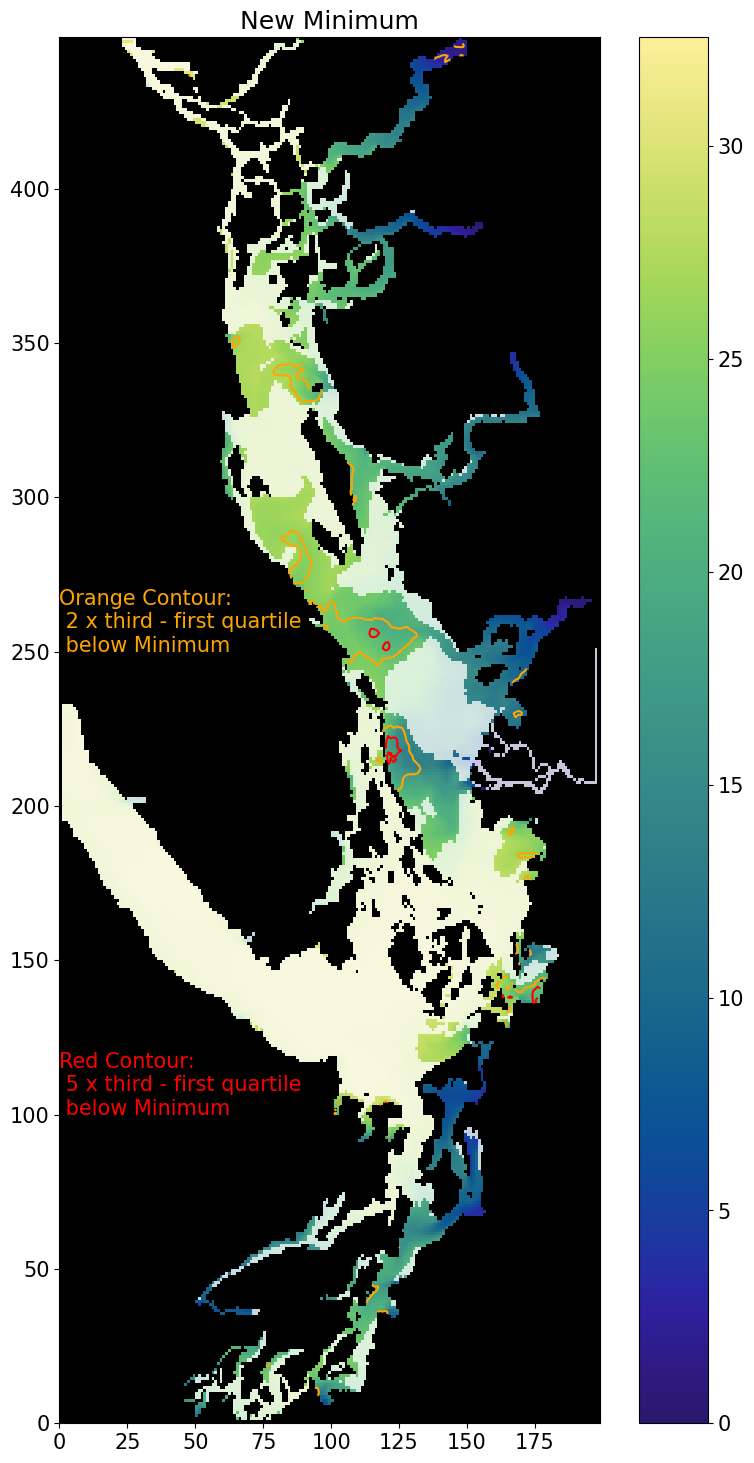

In [177]:
fig, ax = plt.subplots(1, 1, figsize=(10, 18))
ax.pcolormesh(tmask[dl*step, ::step, ::step], cmap='binary_r')
ax.pcolormesh(now_values[dl], vmax=vmax, alpha=alpha, cmap=cmap)
colours = ax.pcolormesh(np.ma.array(now[dl],mask=1-min_mask[dl]), vmin=vmin, vmax=vmax, cmap=cmap)
ax.set_title('New Minimum');
fig.colorbar(colours, ax=ax);
ax.contour(extreme_low[dl], [2, 5], colors=['orange', 'r'])
ax.text(0, 250, 'Orange Contour:\n 2 x third - first quartile\n below Minimum', color='orange')
ax.text(0, 100, 'Red Contour:\n 5 x third - first quartile\n below Minimum', color='r')

viz_tools.set_aspect(ax);

In [207]:
# a point 120, 250
def plot_cross(dl):
    ii, js, je = 250, 80, 145
    fig, ax = plt.subplots(1, 1)
    ax.plot(now_values[dl, ii, js:je])
    ax.plot(median_values[dl, ii, js:je], linewidth=3)
    ax.plot(low_values[dl, ii, js:je], c='tab:orange')
    ax.plot(min_values[dl, ii, js:je], c='tab:orange')
    ax.plot(high_values[dl, ii, js:je], c='tab:orange')
    ax.plot(max_values[dl, ii, js:je], c='tab:orange');
    ax.set_title(f'Across Strait North of Gabriola, depth = {deptht[dl*step].values}');

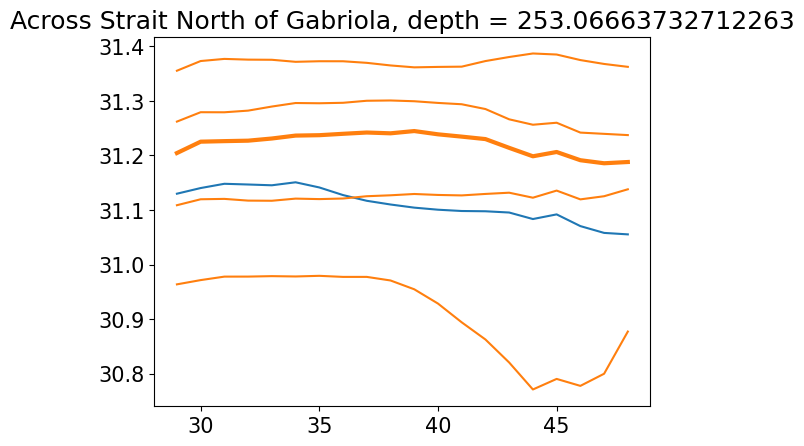

In [208]:
plot_cross(16)

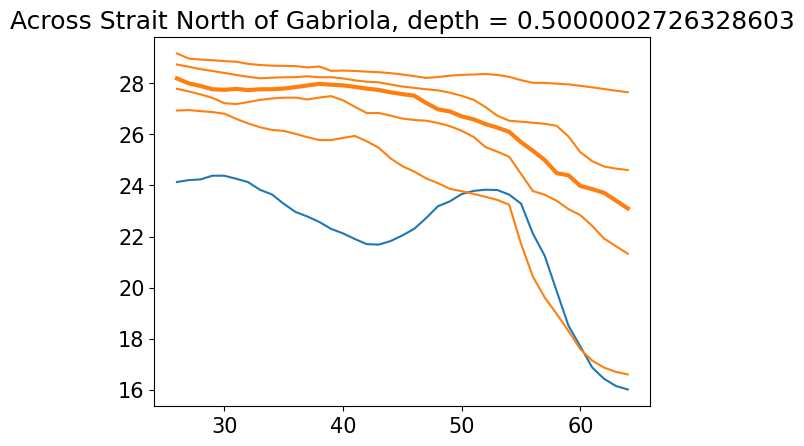

In [209]:
plot_cross(0)